## 0. Imports and Definitions

In [1]:
# Umap of Latent space

In [2]:
import socket

print(socket.gethostname())
assert "login" not in socket.gethostname()

gpu27.cluster.embl.de


In [3]:
import os
import random

os.environ["JAX_ENABLE_X64"] = "False"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import jax

jax.config.update("jax_disable_jit", True)
jax.config.update("jax_enable_x64", False)

import scanpy as sc
import mofaflex as mfl
import scvi
from drvi.model import DRVI
from tqdm import tqdm

import anndata as ad
from mudata import MuData
import pertpy as pt

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
from sklearn.decomposition import PCA

import numpy as np
from seaborn import clustermap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import importlib
import sys

try:
    importlib.reload(sys.modules["src.analysis.plotting"])
    importlib.reload(sys.modules["src.utils.utils"])
    importlib.reload(sys.modules["src.model.data_utils"])
    importlib.reload(sys.modules["src.model.training_utils"])
    importlib.reload(sys.modules["src.model.loss_utils"])
    importlib.reload(sys.modules["src.utils.zinb"])
    importlib.reload(sys.modules["src.model.build_model"])
    importlib.reload(sys.modules["src.model.me_metrics"])
    importlib.reload(sys.modules["src.analysis.analysis_utils"])
except KeyError:
    pass
from src.utils.utils import (
    compute_counterfactual_distances,
    compute_nearest_neighbor_distances,
    compute_latent_effect,
    compute_correlations,
    reverse_dict,
    display_csv,
    compare_pca,
    compute_neighbors,
)
from src.utils.zinb import inferr_zinb_params

from src.analysis.plotting import (
    plot_MPMI,
    plot_ME_spectrum,
    plot_loss,
    plot_umap,
    plot_hist,
    compare_spectra,
    compare_latent_effects,
)
from src.analysis.me_metrics import get_jacobian, get_MPMI, get_manifold_entropy
from src.analysis.analysis_utils import (
    get_losses_ablation,
    analyze_model,
    analyze_result,
    get_ME_spectra_ablation,
    return_bottleneck_representation,
    test_latent_shape,
)

from src.model.data_utils import (
    load_data,
    prepare_data,
    get_condition_shapes,
)
from src.model.training_utils import train_INN
from src.model.build_model import get_INN, ModelConfig
from src.model.INNs import get_linear_INN

import plotly.graph_objects as go

import gc
import warnings
import socket
import torch
from torch.utils.data import DataLoader

assert "login" not in socket.gethostname()

warnings.filterwarnings("ignore", category=FutureWarning)

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

## 1. Loading and Preprocessing

In [5]:
dataset_args = {
    "dataset_name": "kang",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

In [6]:
adata, labels_key, control_label = load_data(
    dataset_args["dataset_name"],
    dataset_args["top_genes"],
    log_transform=True,
    # cell_types=["CD4 Memory"],
)
# sc.experimental.pp.normalize_pearson_residuals(adata)
mdata = MuData({"rna": adata})

AnnData object with n_obs × n_vars = 17913 × 6159
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'patient', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_counts'
    var: 'name', 'n_cells'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'


## 1.1 Gaussian Data

In [565]:
def create_gaussian(n_samples, n_dim):

    mean = np.zeros(n_dim, dtype=np.float32)
    cov = np.zeros((n_dim, n_dim), dtype=np.float32)

    return np.random.multivariate_normal(mean, cov, size=n_samples).astype(np.float32)

In [566]:
gaussian_data = create_gaussian(n_samples=adata.shape[0], n_dim=adata.shape[1])
adata.X = gaussian_data

## 2. Visualize

### 2.1 ZINB

In [ ]:
inferr_zinb_params(adata, gene=119)

### 2.2 UMAP

In [ ]:
sc.pl.umap(adata, color="cell_type")
sc.pl.umap(adata, color="condition")

## 3. E-Distance and E-Test

In [ ]:
distance = pt.tl.Distance("edistance")
df_condition = distance.pairwise(adata, groupby="condition")
df_cell_type = distance.pairwise(adata, groupby="cell_type")

In [ ]:
df_condition.head()

In [ ]:
clustermap(df_cell_type, robust=True, figsize=(5, 5))
plt.show()
clustermap(df_condition, robust=True, figsize=(5, 5))
plt.show()

In [ ]:
etest = pt.tl.DistanceTest("edistance", obsm_key="X_pca", n_perms=500, alpha=0.0015)
tab = etest(adata, groupby="condition", contrast="ctrl")

In [ ]:
tab.head()

In [ ]:
with sns.axes_style("darkgrid"):
    sns.scatterplot(
        data=tab[tab.index != "ctrl"],
        x="pvalue",
        y="distance",
        hue="significant",
        palette={True: "green", False: "red"},
    )
plt.title("E-test results")
plt.xlabel("E-test p-value")
plt.ylabel("E-distance to contrast group (control)")
plt.show()

## 4. DE Analysis

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="condition", method="wilcoxon")
sc.pl.rank_genes_groups(adata)
sc.pl.rank_genes_groups_dotplot(adata, groupby="condition", standard_scale="var", n_genes=20)

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata)
sc.pl.rank_genes_groups_dotplot(adata, groupby="cell_type", standard_scale="var", n_genes=10)

## 5. MOFAFlex

In [61]:
mofa_path = os.path.join(
    "./models",
    "mofa",
    dataset_args["dataset_name"] + "_" + str(dataset_args["top_genes"]) + "_mofa_checkpoint.h5",
)
checkpoint_exists = os.path.exists(mofa_path)

if checkpoint_exists:
    mofa_model = mfl.MOFAFLEX.load(mofa_path)
else:
    mofa_model = mfl.MOFAFLEX(
        mdata,
        mfl.ModelOptions(n_factors=15),
        mfl.TrainingOptions(batch_size=1000, save_path=mofa_path, max_epochs=1000),
    )

In [ ]:
mfl.pl.training_curve(mofa_model)

In [ ]:
mfl.pl.factor_correlation(mofa_model)

In [ ]:
mfl.pl.variance_explained(mofa_model)

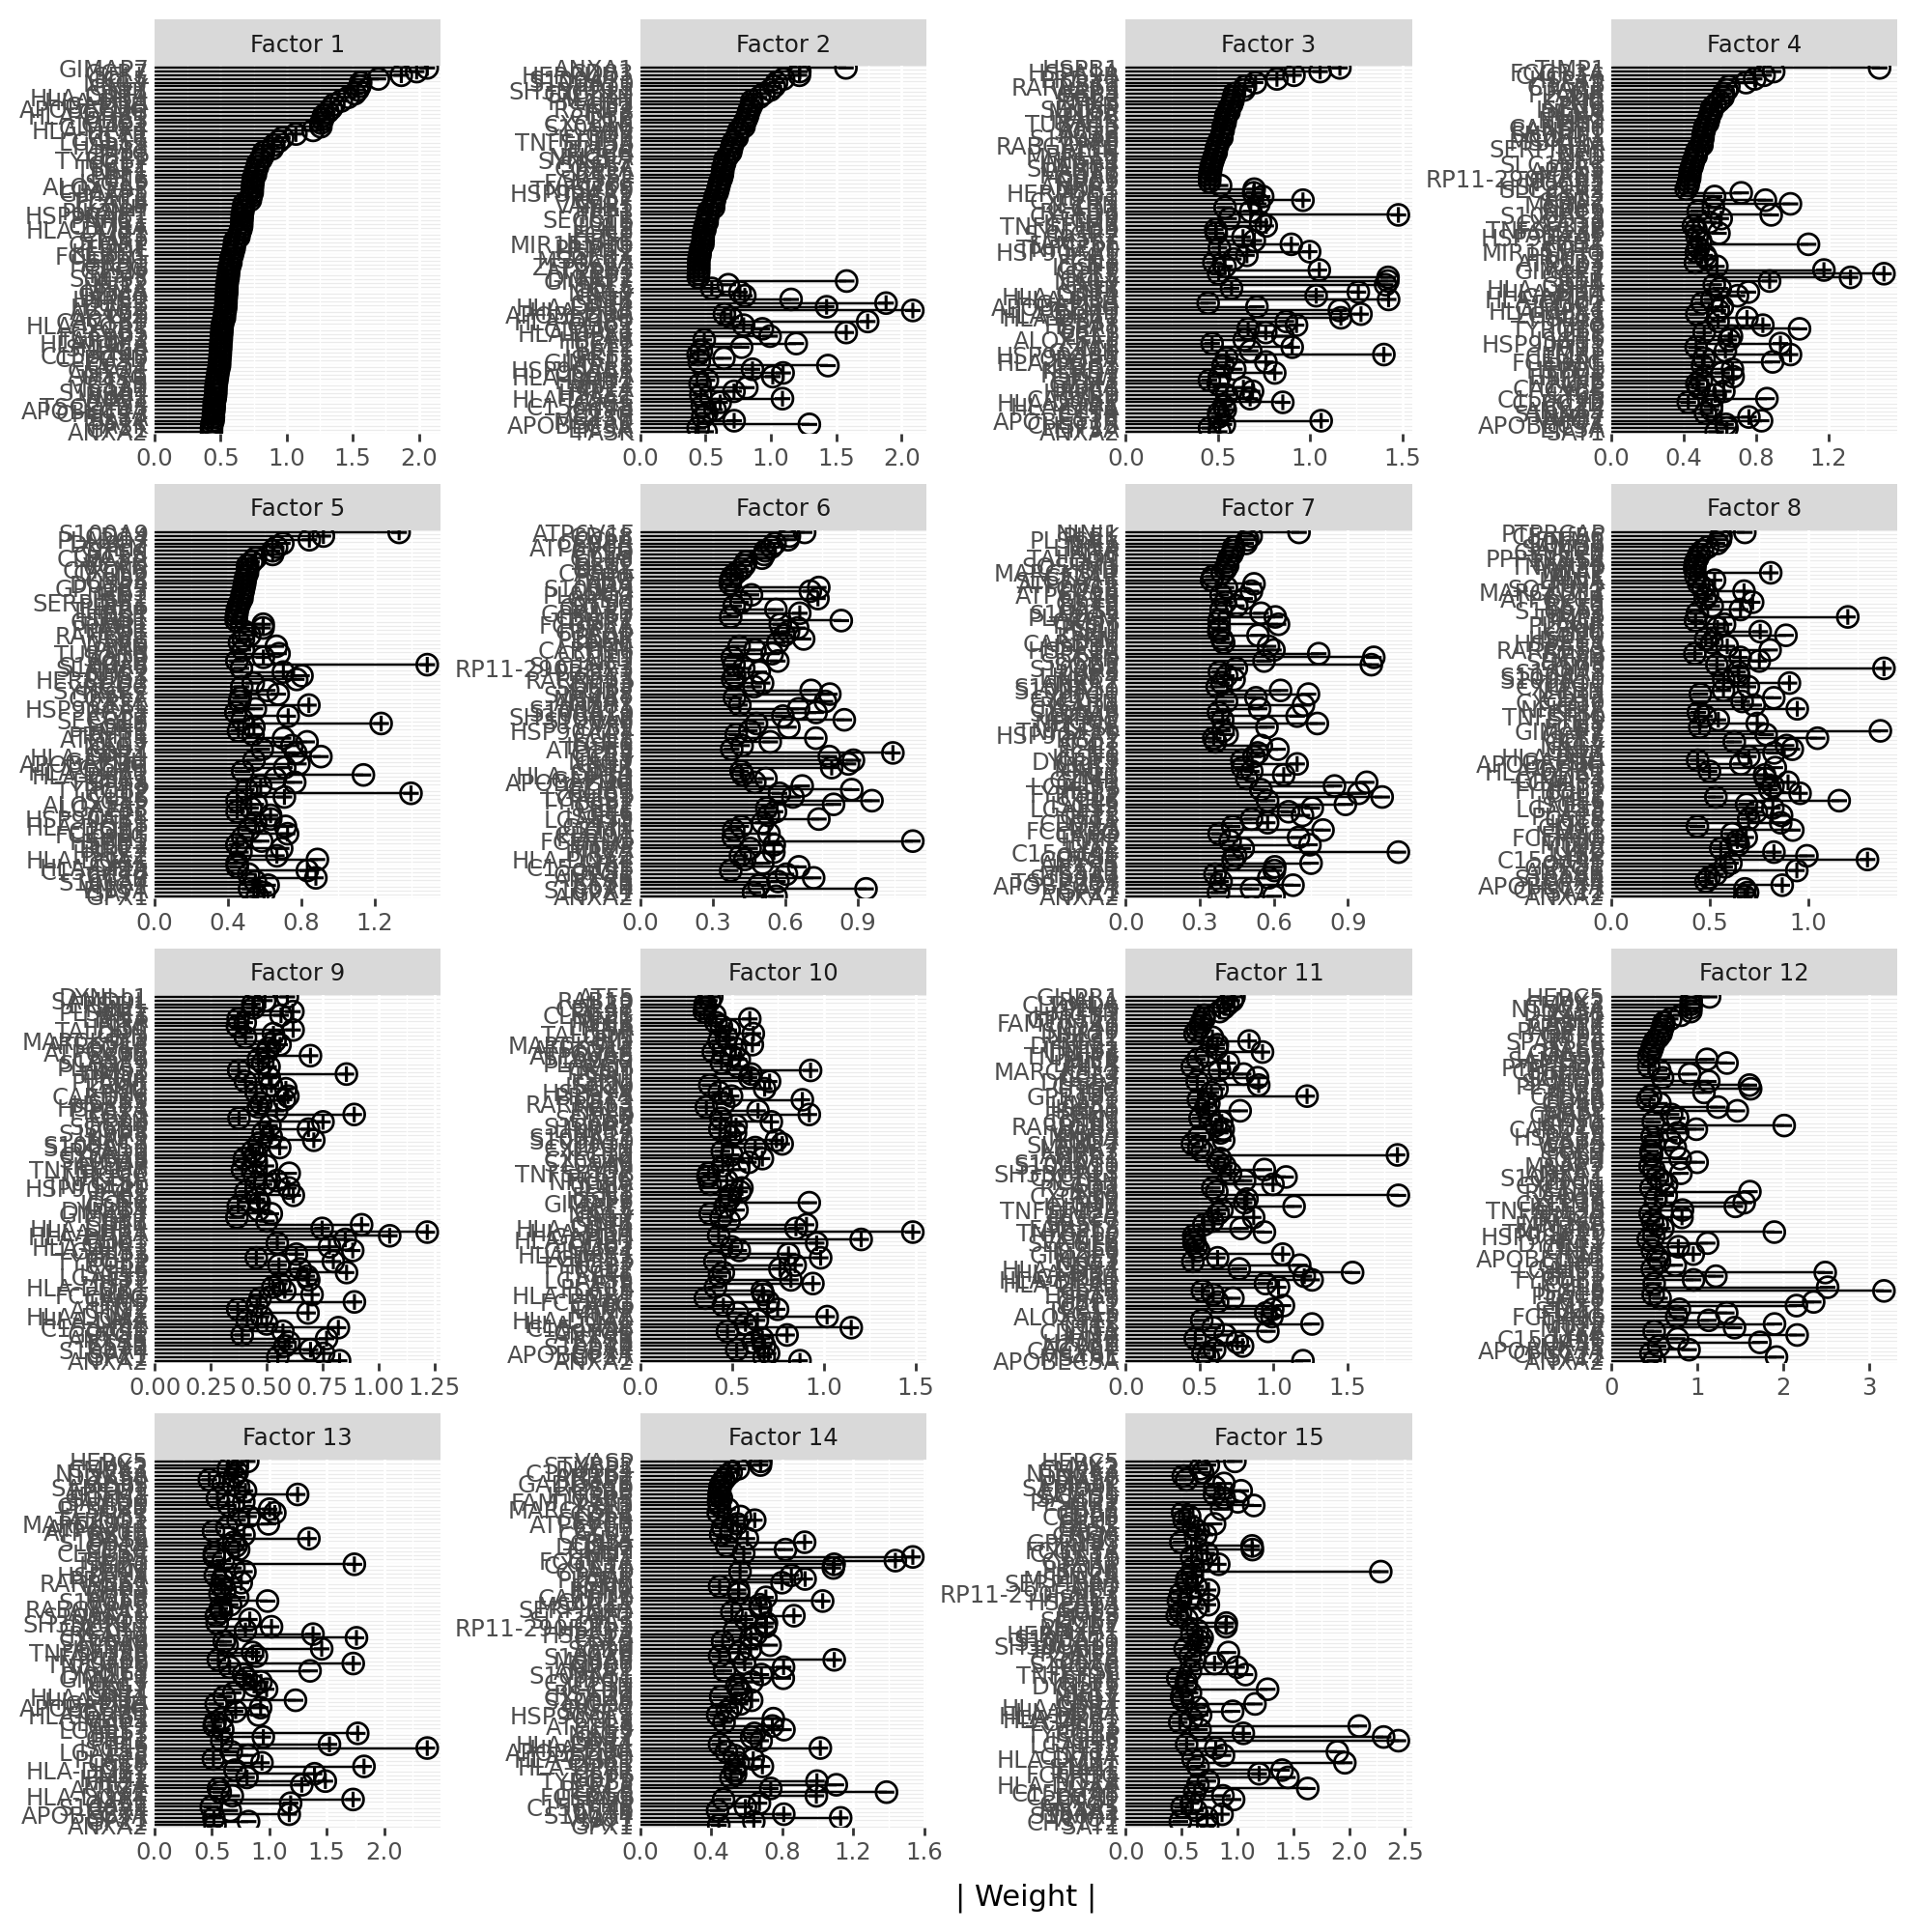

In [65]:
mfl.pl.top_weights(mofa_model, figsize=(10, 10), n_features=100)

In [144]:
Z_mofa = mofa_model.get_factors()["group_1"]
adata.obsm["X_mofa"] = Z_mofa

In [ ]:
sc.pl.umap(adata, color="cell_type", basis="X_mofa")

## 6. scVI

### 6.1 Model Loading

In [7]:
model_name = dataset_args["dataset_name"] + "_" + str(dataset_args["top_genes"]) + "_model.pt"

In [8]:
model_dir = os.path.join("models", "scvi_model")
model_dir_unsupervised = os.path.join("models", "scvi_model_unsupervised")

checkpoint_exists = os.path.exists(os.path.join(model_dir, model_name))
checkpoint_exists_unsupervised = os.path.exists(os.path.join(model_dir_unsupervised, model_name))

print(checkpoint_exists_unsupervised)

True


In [9]:
# if not checkpoint_exists:
#     scvi.model.SCVI.setup_anndata(adata, layer="counts", categorical_covariate_keys=["condition"])
#     scvi_model = scvi.model.SCVI(adata)
#     scvi_model.train(train_size=0.8, check_val_every_n_epoch=5, early_stopping=True)
#     scvi_model.save(model_dir, overwrite=True, anndata_write_kwargs={"filename": model_name})
# else:
#     scvi_model = scvi.model.SCVI.load(
#         model_dir,
#         adata=adata,
#         prefix=dataset_args["dataset_name"] + "_" + str(dataset_args["top_genes"]) + "_",
#     )

In [10]:
if not checkpoint_exists_unsupervised:
    scvi.model.SCVI.setup_anndata(adata, layer="counts")
    scvi_model_unsupervised = scvi.model.SCVI(adata)
    scvi_model_unsupervised.train(train_size=0.8, check_val_every_n_epoch=5, early_stopping=True)
    scvi_model_unsupervised.save(
        model_dir_unsupervised,
        overwrite=True,
        anndata_write_kwargs={"filename": model_name},
    )
else:
    scvi_model_unsupervised = scvi.model.SCVI.load(
        model_dir_unsupervised,
        adata=adata,
        prefix=dataset_args["dataset_name"] + "_" + str(dataset_args["top_genes"]) + "_",
    )

INFO     File models/scvi_model_unsupervised/kang_2000_model.pt already downloaded                                 


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.


In [11]:
# SCVI_LATENT_KEY = "X_scVI"

# Z_scvi = scvi_model.get_latent_representation()
# adata.obsm[SCVI_LATENT_KEY] = Z_scvi

SCVI_LATENT_KEY_UNSUPERVISED = "X_scVI_un"

Z_scvi_unsupervised = scvi_model_unsupervised.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY_UNSUPERVISED] = Z_scvi_unsupervised

### 6.2 Evaluation

In [ ]:
hist = scvi_model.history


def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

In [ ]:
# Reconstruction loss
plot_metric(
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "Reconstruction loss",
    "Negative log likelihood",
)

In [ ]:
reps = ["X_pca", "X_scVI", "X_scVI_un"]
titles = ["PCA", "scVI", "scVI un"]

colors = ["cell_type", "condition"]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
for i, rep in enumerate(reps):
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)

    for j, color in enumerate(colors):
        sc.pl.umap(
            adata,
            color=color,
            ax=axes[i, j],
            show=False,
            title=f"{titles[i]} - {color}",
        )

plt.tight_layout()
plt.show()

## 7. ConstrativeVI

In [ ]:
adata

In [ ]:
model_dir = os.path.join("models", "contrastiveVI_model")
model_name = dataset_args["dataset_name"] + "_" + str(dataset_args["top_genes"]) + "_model.pt"

In [ ]:
if not os.path.exists(os.path.join(model_dir, model_name)):
    scvi.external.ContrastiveVI.setup_anndata(adata, layer="counts")
    contrastive_vi_model = scvi.external.ContrastiveVI(
        adata, n_salient_latent=10, n_background_latent=10, use_observed_lib_size=False
    )
    background_indices = np.where(adata.obs["condition"] == "ctrl")[0]
    target_indices = np.where(adata.obs["condition"] != "ctrl")[0]
    contrastive_vi_model.train(
        background_indices=background_indices,
        target_indices=target_indices,
        early_stopping=True,
        max_epochs=500,
    )
    contrastive_vi_model.save(
        model_dir, overwrite=True, anndata_write_kwargs={"filename": model_name}
    )
else:
    contrastive_vi_model = scvi.external.ContrastiveVI.load(
        model_dir, adata=adata, prefix=dataset + "_"
    )

In [ ]:
perturbed_adata = adata[adata.obs["condition"] != "ctrl"]
perturbed_adata.obsm["salient_rep"] = contrastive_vi_model.get_latent_representation(
    perturbed_adata, representation_kind="salient"
)

sc.pp.neighbors(perturbed_adata)
sc.tl.umap(perturbed_adata)
sc.pl.umap(perturbed_adata, color=["cell_type", "condition"])

In [ ]:
sc.pp.neighbors(perturbed_adata, use_rep="salient_rep")
sc.tl.umap(perturbed_adata)
sc.pl.umap(perturbed_adata, color=["phase", "gene_program"])

## 8. DRVI

In [ ]:
DRVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="condition",
    # In addition to batch_key, you can also provide additional `categorical_covariate_keys`.
    # DRVI accepts count data by default.
    # Set to false if you provide log-normalized data and use normal distribution (mse loss).
    is_count_data=True,
)

## 9. EOFlow

### 9.1 Nearest Neighbor Statistic

In [194]:
nearest_distances_log = []
nearest_distances_orig = []

for i in range(10):
    neighbors_log = compute_nearest_neighbor_distances(adata.X, device=device, k=i + 1)
    nearest_distances_log.append(neighbors_log[:, -1].cpu().numpy())
    neighbors_orig = compute_nearest_neighbor_distances(
        adata.layers["counts"], device=device, k=i + 1
    )
    nearest_distances_orig.append(neighbors_orig[:, -1].cpu().numpy())
nearest_distances_log = np.array(nearest_distances_log)
nearest_distances_orig = np.array(nearest_distances_orig)

mean_nn_dist_log = nearest_distances_log.mean(axis=1).mean()
mean_nn_dist_orig = nearest_distances_orig.mean(axis=1).mean()
print("Mean nearest neighbor distance (log-normalized data):", mean_nn_dist_log)
print("Mean nearest neighbor distance (original counts):", mean_nn_dist_orig)

Mean nearest neighbor distance (log-normalized data): 41.568504
Mean nearest neighbor distance (original counts): 44.81959


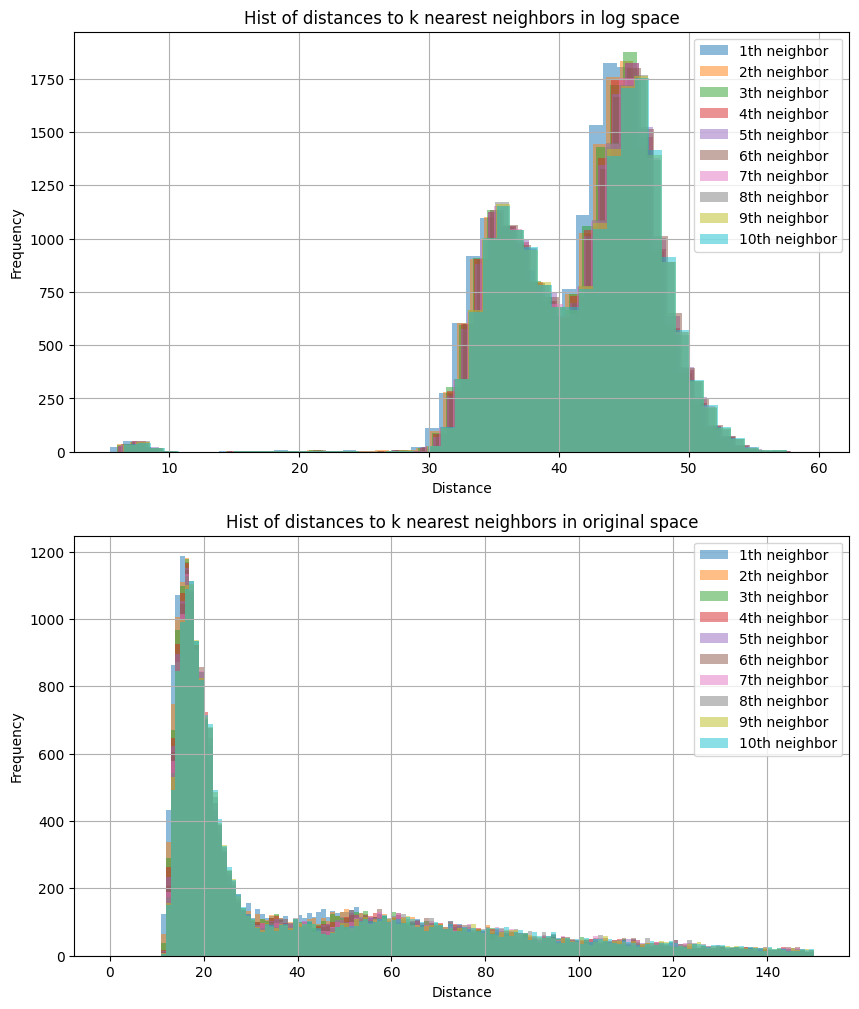

In [195]:
fig, ax = plt.subplots(2, 1, figsize=(10, 12))
for i in range(10):
    ax[0].hist(nearest_distances_log[i], bins=50, alpha=0.5, label=f"{i+1}th neighbor")
    ax[1].hist(
        nearest_distances_orig[i],
        bins=150,
        alpha=0.5,
        label=f"{i+1}th neighbor",
        range=(0, 150),
    )
ax[0].set_title(f"Hist of distances to k nearest neighbors in log space")
ax[1].set_title(f"Hist of distances to k nearest neighbors in original space")
ax[0].set_xlabel("Distance")
ax[1].set_xlabel("Distance")
ax[0].set_ylabel("Frequency")
ax[1].set_ylabel("Frequency")
ax[0].legend()
ax[1].legend()
ax[0].grid(True)
ax[1].grid(True)
plt.show()

In [196]:
noise = 75 / np.sqrt(2000)
print(noise)

0.9167878707749137


### 9.2 Model Setup

In [103]:
dataset_args["sigma_noise"] = 0.51
dataset_args["lam_MTC"] = 1.0
dataset_args["use_counts"] = False
dataset_args["batch_size"] = 64
prefix = ""

In [104]:
conditions = None  # ["condition"]
condition_shapes = None
if conditions is not None:
    condition_shapes = get_condition_shapes(adata, conditions)
print("Condition shapes:", condition_shapes)

Condition shapes: None


In [105]:
dataset, dataloader = prepare_data(
    adata,
    dataset_args["batch_size"],
    device,
    dtype,
    counts=dataset_args["use_counts"],
    label_key=conditions,
)
D_dim = dataset.X.shape[1]
N_dim = D_dim

In [106]:
dataset_name = dataset_args["dataset_name"]
top_genes = min(dataset_args["top_genes"], D_dim)
sigma_noise = dataset_args["sigma_noise"]
lam_MTC = dataset_args["lam_MTC"]

model_path = os.path.join("/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes))
model_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise) + "_model.pt"

output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)
output_dir_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise)

if dataset_args["use_counts"]:
    model_path += "_counts"
    output_dir_path += "_counts"

# model_path += "_small"
# output_dir_path += "_small"
print(f"Model path: {model_path}")

plot_dir = os.path.join(output_dir_path, "plots", output_dir_name)
log_dir = os.path.join(output_dir_path, "logs", output_dir_name)
csv_dir = os.path.join(output_dir_path, "csv", output_dir_name)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

Model path: /g/stegle/jhoefer/models/EOFlow/kang/top_2000


In [107]:
kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataloader": dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": sigma_noise,
    "sigma_inflate": sigma_noise,
}

kwargs_loss = {
    "use_NLL": True,
    "use_MER": True,
    "mode_MER": "unbiased",  #'full', #'unbiased'
    "lam_MTC": lam_MTC,
    "lam_ME_i": list(np.zeros(D_dim)),
    # 'use_align': False,
    # 'dims_align': D_dim - 1,
    # 'lam_align': 1, #0.1,
    # 'lam_disent': 0, #0.1,
    "use_rec": False,
    "dims_rec": D_dim - 1,
    "lam_rec": 100,  #
    "sigma_noise": sigma_noise,
}

metrics_loss = {
    "epoch": [],
    "loss": [],
    "z2": [],
    "NLL": [],
    "MTC": [],
    "H_i": [],
    "H_core": [],
    "H_detail": [],
    "MI_core_detail": [],
    "L2_rec": [],
}

In [108]:
model_config = ModelConfig(
    N_dim=N_dim,
    N_blocks=6,
    condition_shapes=condition_shapes,
    pre_normalize=False,
)

In [109]:
# flow, optimizer_flow = get_linear_INN(
#     N_dim,
#     lr=1e-3,
#     use_decomposition=False,
#     init_mode="orthogonal",
#     optimizer_type="schedulefree",
#     warmup_steps=100,
#     n_layers=1,
# )
# flow = flow.to(device=device)

In [110]:
# flow, optimizer_flow = get_INN(
#     N_dim=N_dim,
#     condition_shapes=condition_shapes,
#     N_blocks=12,
#     ch_hidden=2048,
#     coupling_block_type="GLOW",
#     RQS_bins=10,
#     lr=1e-3,
#     optimizer_type="schedulefree",
#     warmup_steps=100,
#     pre_normalize=False,
#     normalize=True,
# )
# flow = flow.to(device)

In [111]:
# flow, optimizer_flow = get_INN(
#     N_dim=N_dim,
#     condition_shapes=condition_shapes,
#     N_blocks=2,
#     ch_hidden=2048,
#     coupling_block_type="GLOW",
#     RQS_bins=10,
#     lr=1e-3,
#     optimizer_type="schedulefree",
#     warmup_steps=100,
#     pre_normalize=False,
#     normalize=True,
# )
# flow = flow.to(device)

In [112]:
gc.collect()
torch.cuda.empty_cache()

### 9.3 Training

In [113]:
CONTINUE_TRAINING = True
NUM_EPOCHS = 1
# NUM_EPOCHS = int(NUM_EPOCHS * N_dim / dataset_args["batch_size"])
start_epoch = 0
log_path = None

In [114]:
print(os.path.join(model_path, model_name))

/g/stegle/jhoefer/models/EOFlow/kang/top_2000/MTC_1.0_sigma_0.51_model.pt


In [115]:
if os.path.exists(os.path.join(model_path, model_name)):
    checkpoint = torch.load(
        os.path.join(model_path, model_name),
        map_location=device,
        weights_only=False,
    )

    metrics_loss = checkpoint["metrics_loss"]
    log_path = checkpoint["log_path"]
    start_epoch = checkpoint["epoch"] + 1
    model_config = checkpoint["model_config"]
    print(f"Checkpoint found at epoch {checkpoint['epoch']}.")

    flow, optimizer_flow = get_INN(model_config)
    flow = flow.to(device)
    flow.load_state_dict(checkpoint["model_state_dict"])
    optimizer_flow.load_state_dict(checkpoint["optimizer_state_dict"])
else:
    flow, optimizer_flow = get_INN(model_config)
    flow = flow.to(device)


if CONTINUE_TRAINING:
    print(f"Starting training from epoch {start_epoch}...")

    flow, optimizer_flow, metrics_loss, log_path = train_INN(
        flow,
        optimizer_flow,
        metrics_loss,
        kwargs_data,
        kwargs_loss,
        model_config=model_config,
        save_model_path=os.path.join(model_path, model_name),
        num_epochs=NUM_EPOCHS,
        start_epoch=start_epoch,
        print_info=True,
        log_dir=log_dir,
        continue_log_path=log_path,
        conditions=conditions,
        use_counts=dataset_args["use_counts"],
    )

Checkpoint found at epoch 12.
Starting training from epoch 13...
Sigma noise: 0.51
Average time per update: 0.3809 seconds


### 9.4 Analysis

In [135]:
 max(1, np.ceil(70000 * 64 / adata.X.shape[0]).astype(int))

np.int64(251)

#### 9.4.1 Factors

##### 9.4.1.0 Helper Functions

In [116]:
def get_gene_importances(jac_dec, top_k=10, location=None):
    if location is None:
        gene_importances = torch.median(torch.abs(jac_dec), dim=0).values
    else:
        gene_importances = torch.abs(jac_dec[location])
    top_genes = torch.topk(gene_importances, k=top_k, dim=0)
    return top_genes


def draw_single_factor_on_ax(ax, jac_dec, top_genes, factor_idx, gene_names, top_k=10):
    """Helper function to draw one lollipop plot on a provided axis."""
    # 1. Get indices and absolute values
    indices = top_genes.indices[:, factor_idx].cpu().numpy()
    abs_weights = top_genes.values[:, factor_idx].cpu().numpy()

    # 2. Get directionality (consensus sign across samples)
    raw_mean = jac_dec[:, indices, factor_idx].mean(dim=0).cpu().numpy()
    signs = np.sign(raw_mean)

    # 3. Get gene names
    names = [gene_names[i] for i in indices]

    # --- Plotting Logic ---
    y_pos = np.arange(top_k)[::-1]
    ax.hlines(y_pos, 0, abs_weights, color="black", linewidth=1.2)

    for i, (val, s) in enumerate(zip(abs_weights, signs)):
        marker = "+" if s >= 0 else "−"
        ax.plot(
            val,
            y_pos[i],
            "o",
            markersize=14,
            color="black",
            markerfacecolor="white",
            markeredgewidth=1.2,
        )
        ax.text(val, y_pos[i], marker, ha="center", va="center", fontsize=10, fontweight="bold")

    # Styling
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=10)
    ax.set_title(f"Factor {factor_idx}", backgroundcolor="#D8ABAB", pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", alpha=0.2)


def plot_factors_grid(jac_dec, top_genes, factor_indices, gene_names, top_k=10, n_cols=4):
    """Plots a grid of factor weights."""
    factor_indices = np.arange(factor_indices)
    n_factors = len(factor_indices)
    n_rows = int(np.ceil(n_factors / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = np.array(axes).flatten()  # Flatten in case of 1D or 2D array

    for i, factor_idx in enumerate(factor_indices):
        draw_single_factor_on_ax(axes[i], jac_dec, top_genes, factor_idx, gene_names, top_k)

    # Hide empty subplots if n_factors isn't a perfect multiple of n_cols
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def filter_xdata(adata, covariates, keys):

    mask = np.ones(adata.shape[0], dtype=np.bool)
    if covariates is not None and keys is not None:
        for covariate, key in zip(covariates, keys):
            mask &= adata.obs[covariate] == key

    x_data = adata[mask, :].X
    x_data = x_data.toarray()
    x_data = torch.tensor(x_data, dtype=torch.float32, device=device)

    return x_data[:256, :]


def plot_factors_for_covariate(
    adata, covariates, keys, kwargs_data, flow, top_k=10, location=None, condition_shapes=None
):
    x_data = filter_xdata(adata, covariates, keys)

    jac_dec, ljd, z, x = get_jacobian(
        kwargs_data,
        flow,
        condition_shapes=condition_shapes,
        print_info=False,
        x_input=x_data,
        subtract_mean=False,
    )

    top_genes = get_gene_importances(jac_dec, top_k=top_k, location=location)
    plot_factors_grid(
        jac_dec, top_genes, factor_indices=4, gene_names=adata.var["name"].tolist(), top_k=top_k
    )

In [ ]:
from src.utils.utils import augment_with_noise


def pca_draw_single_factor_on_ax(ax, top_genes, factor_idx, gene_names, top_k=10):
    """Helper function to draw one lollipop plot on a provided axis."""
    # 1. Get indices and absolute values
    indices = top_genes.indices[factor_idx, :].cpu().numpy()
    weights = top_genes.values[factor_idx, :].cpu().numpy()

    # 2. Get directionality (consensus sign across samples)
    signs = np.sign(weights)

    weights = np.abs(weights)
    sort = np.argsort(weights)[::-1]
    weights = weights[sort]
    signs = signs[sort]
    indices = indices[sort]

    # 3. Get gene names
    names = [gene_names[i] for i in indices]

    # --- Plotting Logic ---
    y_pos = np.arange(top_k)[::-1]
    ax.hlines(y_pos, 0, weights, color="black", linewidth=1.2)

    for i, (val, s) in enumerate(zip(weights, signs)):
        marker = "+" if s >= 0 else "−"
        ax.plot(
            val,
            y_pos[i],
            "o",
            markersize=14,
            color="black",
            markerfacecolor="white",
            markeredgewidth=1.2,
        )
        ax.text(val, y_pos[i], marker, ha="center", va="center", fontsize=10, fontweight="bold")

    # Styling
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=10)
    ax.set_title(f"Factor {factor_idx}", backgroundcolor="#D8ABAB", pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", alpha=0.2)


def pca_plot_factors_grid(top_genes, factor_indices, gene_names, top_k=10, n_cols=4):
    """Plots a grid of factor weights."""
    factor_indices = np.arange(factor_indices)
    n_factors = len(factor_indices)
    n_rows = int(np.ceil(n_factors / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = np.array(axes).flatten()  # Flatten in case of 1D or 2D array

    for i, factor_idx in enumerate(factor_indices):
        pca_draw_single_factor_on_ax(axes[i], top_genes, factor_idx, gene_names, top_k)

    # Hide empty subplots if n_factors isn't a perfect multiple of n_cols
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def pca_get_gene_importances(adata, noise_level, top_k=10):
    if hasattr(adata.X, "toarray"):
        X = adata.X.toarray()
    else:
        X = adata.X.copy()

    noise_levels = [noise_level / x for x in [1]] if noise_level > 0 else []
    X_augmented = augment_with_noise(X, noise_levels)

    pca = PCA(n_components=None)
    X_pca = pca.fit_transform(X_augmented)
    latent_order = np.argsort(pca.explained_variance_)[::-1]

    pca_components_ = pca.components_[latent_order][:10]
    pca_components_ = torch.tensor(pca_components_, dtype=torch.float32, device=device)

    top_genes = torch.topk(pca_components_, k=top_k, dim=1)

    return top_genes

##### 9.4.1.1 Plots

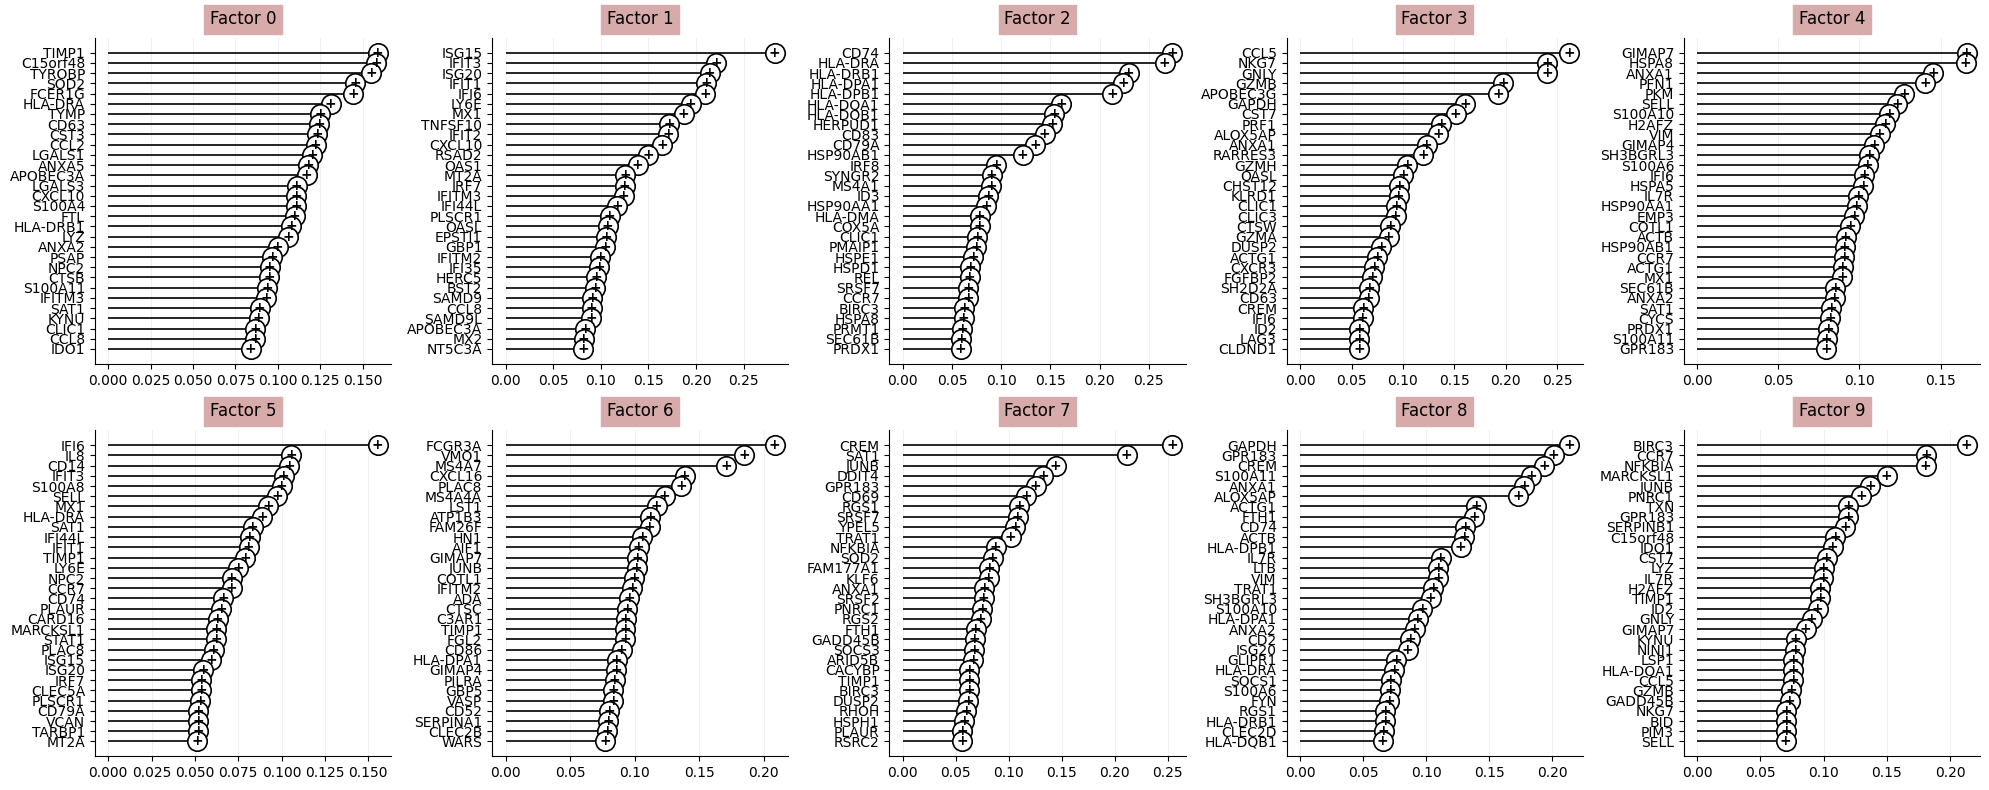

In [ ]:
top_k = 30
pca_top_genes = pca_get_gene_importances(adata, noise_level=0.4, top_k=top_k)
pca_plot_factors_grid(
    pca_top_genes, factor_indices=10, gene_names=adata.var_names, top_k=top_k, n_cols=5
)

before forward: 9063.7 MiB
after forward: 9382.1 MiB


after grad: 13288.4 MiB


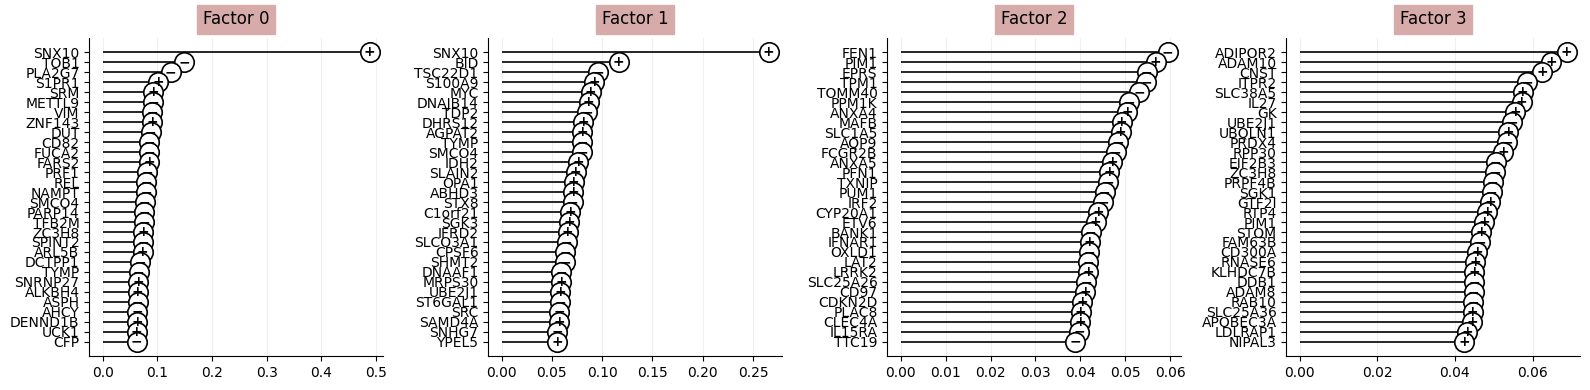

In [ ]:
top_k = 30
cell_names = adata.obs["cell_type"].tolist()
plot_factors_for_covariate(
    adata,
    covariates=["cell_type", "condition"],
    keys=[cell_names[0], "stim"],
    kwargs_data=kwargs_data,
    flow=flow,
    top_k=top_k,
    location=None,
    condition_shapes=condition_shapes,
)

before forward: 9063.7 MiB
after forward: 9382.1 MiB
after grad: 13288.4 MiB


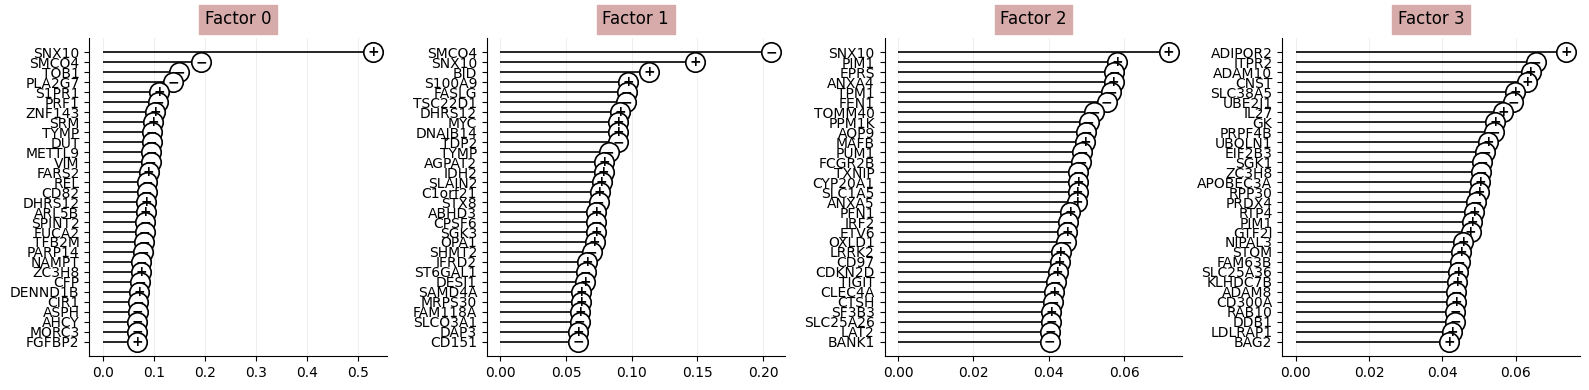

In [ ]:
plot_factors_for_covariate(
    adata,
    covariates=["cell_type", "condition"],
    keys=[cell_names[0], "stim"],
    kwargs_data=kwargs_data,
    flow=flow,
    top_k=top_k,
    location=2,
    condition_shapes=condition_shapes,
)

before forward: 9179.7 MiB
after forward: 9498.0 MiB
after grad: 13404.3 MiB


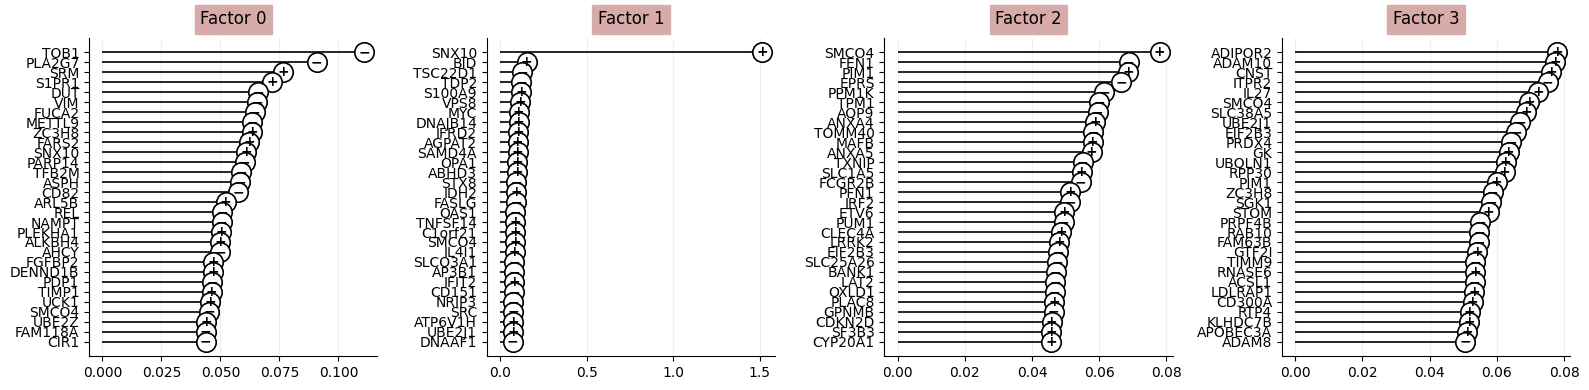

In [ ]:
plot_factors_for_covariate(
    adata,
    covariates=None,
    keys=None,
    kwargs_data=kwargs_data,
    flow=flow,
    top_k=top_k,
    location=None,
    condition_shapes=condition_shapes,
)

In [44]:
# test_latent_shape(flow, adata, latent_sort, device, 500, plot_dir=plot_dir)

#### 9.4.2 Bottlenck UMAP


In [131]:
gc.collect()
torch.cuda.empty_cache()

In [132]:
model_dir = os.path.join("/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes))
z_latent, latent_sort = return_bottleneck_representation(
    adata, model_dir, device, dtype, sigma_noise, lam_MTC, bottleneck_dim=2000
)

Checkpoint found at epoch 150.


/home/jhoefer/sandbox/src/analysis/analysis_utils.py:453: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


before forward: 27131.1 MiB
after forward: 27321.3 MiB
after grad: 29275.3 MiB


100%|███████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8604.77it/s]


In [133]:
print("Latent representation shape:", z_latent.shape)

Latent representation shape: (17913, 2000)


In [134]:
drop = 500

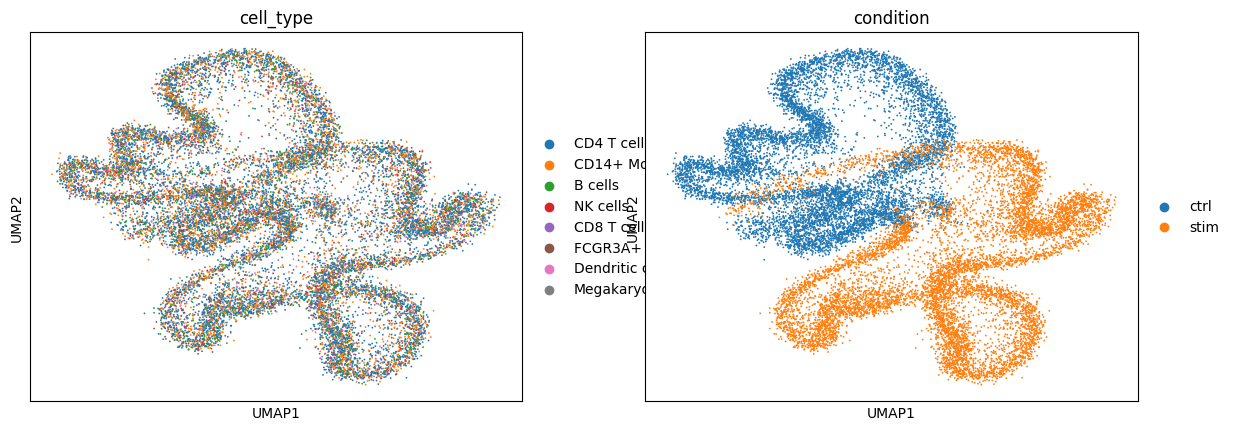

In [135]:
adata.obsm["X_EOFlow"] = z_latent[:, latent_sort[: 2000 - drop]]
sc.pp.neighbors(adata, use_rep="X_EOFlow")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cell_type", "condition"])

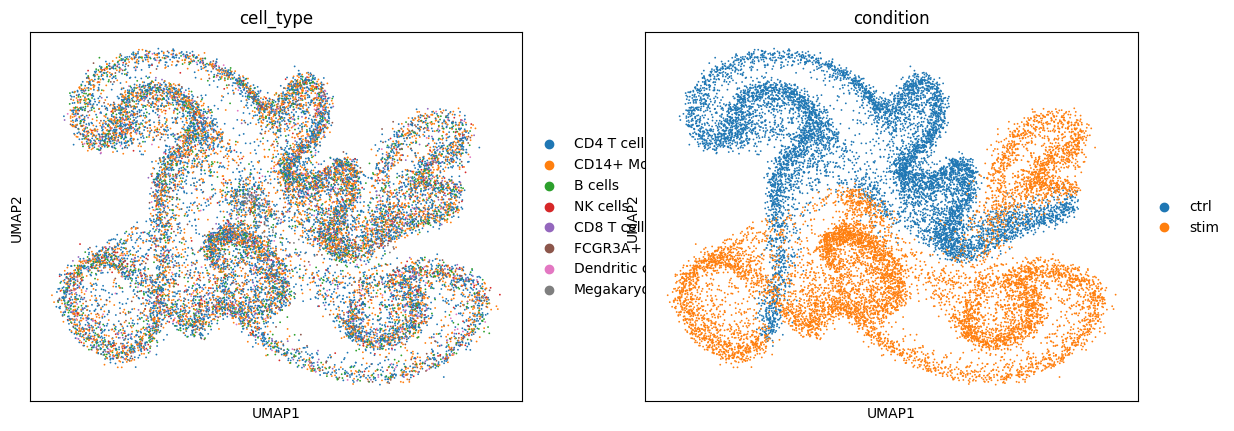

In [136]:
adata.obsm["X_EOFlow"] = z_latent[:, latent_sort[drop:]]
sc.pp.neighbors(adata, use_rep="X_EOFlow")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cell_type", "condition"])

### 9.4.3 Plots

In [25]:
gc.collect()
torch.cuda.empty_cache()

In [26]:
N_samples = 256
idx = torch.randperm(adata.X.shape[0])[:N_samples]
x_input = torch.tensor(adata.X.toarray(), dtype=torch.float32, device=device)[idx]
x_input = x_input + torch.randn_like(x_input) * sigma_noise

jac_dec, ljd, z, x = get_jacobian(
    kwargs_data,
    flow,
    condition_shapes=condition_shapes,
    N_samples=N_samples,
    print_info=False,
    x_input=x_input,
    subtract_mean=False,
)

with torch.no_grad():
    H_i, H, latent_sort = get_manifold_entropy(
        kwargs_data, jac_dec.detach(), ljd.detach(), z=z.detach(), print_info=True
    )

before forward: 4997.0 MiB
after forward: 5312.8 MiB
after grad: 9227.2 MiB


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8148.76it/s]


0it [00:00, ?it/s]


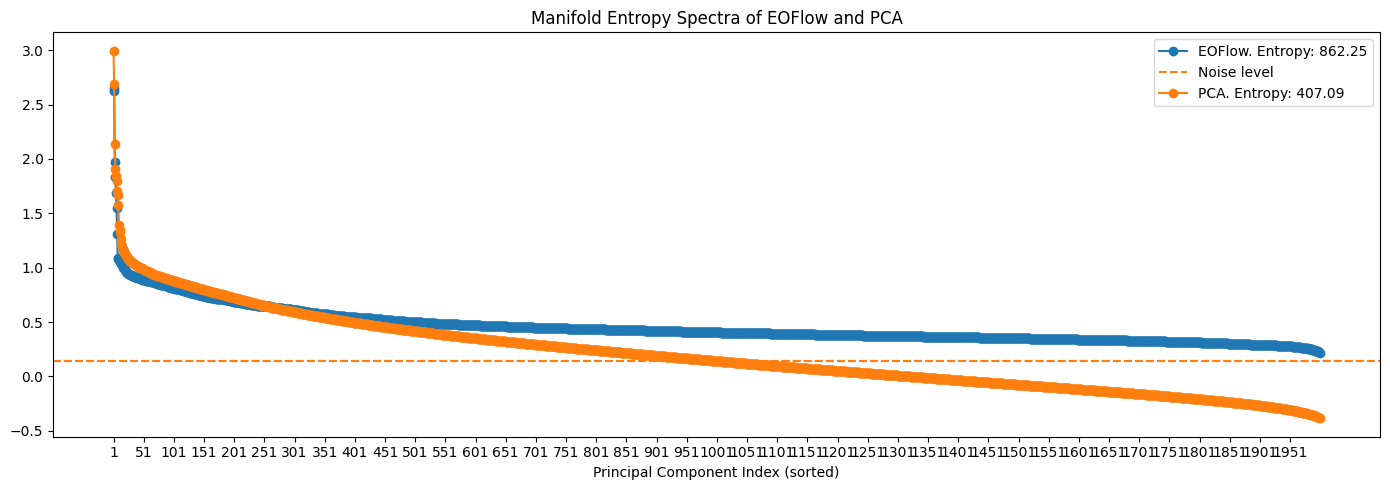

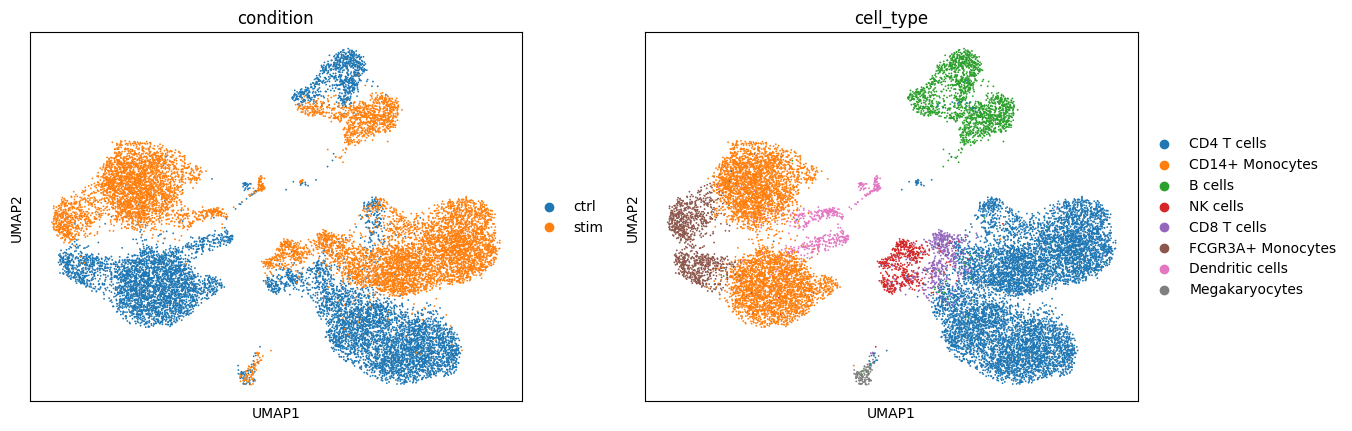

ValueError: Could not broadcast together arguments with shapes: [0, 1, 1].

In [27]:
analyze_result(
    adata,
    flow,
    latent_sort,
    H_i,
    H,
    N_dim,
    metrics_loss,
    conditions=conditions,
    plot_dir=plot_dir,
    device=device,
    log_scale=False,
    sigma_inflate=kwargs_data["sigma_inflate"],
    n_latent_factors=0,
    vmax=1.5,
    labels_key=labels_key,
)

### 9.5 Counterfactuals

In [ ]:
results = []
for i in range(3):
    df_counterfactual = compute_counterfactual_distances(
        flow, adata, device=device, dim_to_flip=latent_sort[i]
    )
    df_counterfactual.columns.name = "Flipped Dim " + str(latent_sort[i].item())
    results.append(df_counterfactual)
    display(df_counterfactual)

In [ ]:
if os.path.exists(os.path.join(csv_dir, "counterfactual_edistances.csv")):
    df = pd.read_csv(os.path.join(csv_dir, "counterfactual_edistances.csv"), index_col=0)
else:
    stim_cfs = []
    ctrl_cfs = []
    for i, df_counterfactual in enumerate(results):
        stim_cfs.append(df_counterfactual["stim"]["stim_cf"])
        ctrl_cfs.append(df_counterfactual["ctrl"]["ctrl_cf"])

    row_names = ["Latent Dim " + str(latent_sort[i].item()) for i in range(3)]
    df = pd.DataFrame({"stim_cfs": stim_cfs, "ctrl_cfs": ctrl_cfs}, index=row_names)
    df.to_csv(os.path.join(csv_dir, "counterfactual_edistances.csv"))

df.style.background_gradient(cmap="coolwarm", axis=None, vmin=-10, vmax=10).format("{:.3f}")

### 9.6 Correlations with covariates

In [80]:
correlations = compute_correlations(
    adata,
    flow,
    latent_sort=latent_sort[:15],
    device=device,
    label_keys=["cytokine", "cell_type"],
)

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


In [81]:
df = pd.DataFrame(
    {
        latent: dict(values)  # convert list of tuples to dict for each latent
        for latent, values in correlations.items()
    }
)
df.to_csv(os.path.join(csv_dir, "correlations.csv"))
df.style.background_gradient(cmap="coolwarm", axis=None, vmin=-1, vmax=1).format("{:.3f}")

,latent_1023,latent_222,latent_707,latent_1062,latent_337,latent_1500,latent_997,latent_1049,latent_1325,latent_885,latent_206,latent_1030,latent_135,latent_1367,latent_1560
CD27L,0.000,-0.013,-0.000,0.005,-0.005,0.007,-0.034,0.054,-0.003,0.020,0.005,0.047,0.005,0.011,-0.032
CD40L,-0.008,-0.027,0.013,0.042,0.009,-0.017,-0.027,-0.017,0.004,0.040,-0.011,0.056,0.003,-0.006,-0.028
CT-1,0.003,-0.026,0.025,0.100,-0.010,-0.022,0.086,-0.138,0.057,-0.001,0.017,0.051,-0.005,0.003,-0.034
FGF-beta,-0.004,-0.017,0.021,0.039,0.002,0.001,-0.000,0.016,-0.010,-0.012,0.008,0.038,0.001,0.018,-0.019
IFN-epsilon,-0.024,-0.032,0.021,0.064,0.009,-0.022,0.044,-0.011,0.035,0.023,0.020,0.061,-0.007,0.000,-0.040
IL-1-beta,0.037,0.032,-0.051,-0.101,-0.023,0.053,-0.314,0.212,-0.081,0.022,0.034,0.007,0.028,-0.026,0.001
IL-13,-0.005,-0.019,0.014,0.074,0.008,0.001,0.001,0.014,0.015,-0.013,0.016,0.035,0.004,-0.008,0.016
IL-2,0.031,0.039,-0.051,-0.038,-0.020,0.041,-0.233,0.077,-0.077,-0.026,-0.024,-0.005,0.021,-0.039,0.040
IL-32-beta,0.011,0.017,0.005,-0.012,-0.002,0.003,0.170,0.050,0.224,0.003,-0.009,-0.118,-0.004,0.019,0.054
IL-4,-0.046,0.012,0.014,-0.153,0.048,-0.068,0.288,-0.387,-0.061,0.030,-0.061,-0.128,-0.058,-0.053,0.048


### 9.7 Correlations of dims

In [82]:
max_dim = min(50, kwargs_data["N_dim"])
MPMI_flow = get_MPMI(
    kwargs_data,
    jac_dec[:, latent_sort],
    jac_dec[:, latent_sort],
    max_dim=max_dim,
    dtype=torch.float64,
    device="cpu",
    take_mean=False,
)  # [:,latent_sort_gt_polygon]

MPMI_flow = MPMI_flow + MPMI_flow.transpose(1, 2)

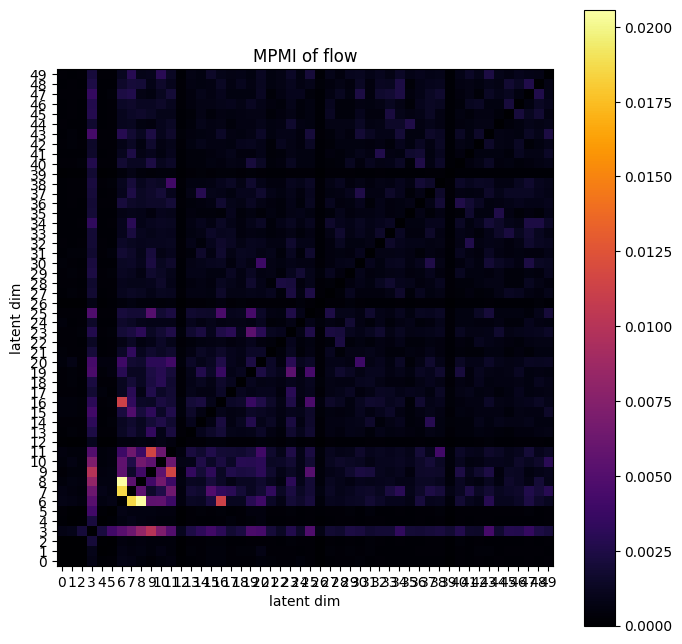

In [83]:
plot_MPMI(
    MPMI_flow.mean(0).numpy(),
    z_max=max_dim,
    title=f"MPMI of flow",
    dim_label="latent dim",
    figsize=8,
)  # , vmin=0, vmax=0.1)

### 9.8 Ablation Plots

In [25]:
default_dir_name = "/g/stegle/jhoefer/models/EOFlow/kang/top_2000"
transformed_dir_name = default_dir_name + "_ablation"
count_dir_name = default_dir_name + "_counts_ablation"

In [ ]:
transformed_losses = get_losses_ablation(transformed_dir_name, device)
count_losses = get_losses_ablation(count_dir_name, device)

Evalutating model: MTC_0.0_sigma_0.4_model.pt


In [ ]:
noise_levels = transformed_losses.keys()
noise_levels = sorted(noise_levels, key=lambda x: float(x))

fig, ax = plt.subplots(len(noise_levels), 2, figsize=(15, 15))
for i, sigma in enumerate(noise_levels):
    for lambd_MTC in transformed_losses[sigma].keys():
        ax[i][0].plot(transformed_losses[sigma][lambd_MTC], label=f"Noise: {lambd_MTC}")
        ax[i][1].plot(count_losses[sigma][lambd_MTC], label=f"Noise: {lambd_MTC}")
        ax[i][0].set_title(f"Transformed - Noise Level: {sigma}")
        ax[i][1].set_title(f"Counts - Noise Level: {sigma}")
        ax[i][1].set_ylim(-1, 2)
        ax[i][0].set_xlabel("Epoch")
        ax[i][1].set_xlabel("Epoch")
        ax[i][0].set_ylabel("Loss")
        ax[i][1].set_ylabel("Loss")
        ax[i][0].legend()
        ax[i][1].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir_path, "plots", "losses.png"))
plt.show()

In [ ]:
sigmas = transformed_losses[noise_levels[0]].keys()

min__transformed_losses = {}
min_count_losses = {}
for sigma in noise_levels:
    min__transformed_losses[sigma] = []
    min_count_losses[sigma] = []
    for lambd_MTC in transformed_losses[sigma].keys():
        min__transformed_losses[sigma].append(min(transformed_losses[sigma][lambd_MTC]))
        min_count_losses[sigma].append(min(count_losses[sigma][lambd_MTC]))

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for sigma in noise_levels:
    ax[0].plot(
        sigmas,
        min__transformed_losses[sigma],
        marker="o",
        label=f"Transformed - Noise Level: {sigma}",
    )
    ax[1].plot(sigmas, min_count_losses[sigma], marker="s", label=f"Counts - Noise Level: {sigma}")
ax[0].set_title("Transformed - Minimum Loss across Lambda MTC")
ax[1].set_title("Counts - Minimum Loss across Lambda MTC")
ax[0].set_xlabel("Lambda MTC")
ax[1].set_xlabel("Lambda MTC")
ax[0].set_ylabel("Minimum Loss")
ax[1].set_ylabel("Minimum Loss")
ax[0].legend()
ax[1].legend()
ax[0].grid(True)
ax[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir_path, "plots", "min_loss_comparison.png"))

## 10. Analysis

In [28]:
default_dir_name = "/g/stegle/jhoefer/models/EOFlow/kang/top_2000"
output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)
# transformed_dir_name = default_dir_name + "_ablation"
# count_dir_name = default_dir_name + "_counts_ablation"

In [ ]:
dataset_name = "kang"
top_genes = 2000

model_path = os.path.join("/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes))
print(f"Directory for models: {model_path}")

output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)

# model_path += "_ablation"
# output_dir_path += "_ablation"

sigma_noises = [0.5]
lam_MTCs = [1.0]
prefixes = None  # ["condition"]

for sigma_noise in sigma_noises:
    for lam_MTC in lam_MTCs:
        if prefixes is not None:
            for prefix in prefixes:
                _, _ = analyze_model(
                    adata,
                    model_path,
                    output_dir_path,
                    device,
                    dtype,
                    labels_key=labels_key,
                    batch_size=dataset_args["batch_size"],
                    sigma_noise=sigma_noise,
                    lam_MTC=lam_MTC,
                    N_blocks=12,
                    use_counts=False,
                    umaps=True,
                    correlations=True,
                    conditions=[prefix],
                    prefix=prefix,
                )
        else:
            _, _ = analyze_model(
                adata,
                model_path,
                output_dir_path,
                device,
                dtype,
                labels_key=labels_key,
                batch_size=dataset_args["batch_size"],
                sigma_noise=sigma_noise,
                lam_MTC=lam_MTC,
                N_blocks=12,
                use_counts=False,
                umaps=False,
                correlations=True,
                conditions=None,
                prefix=None,
                pre_normalize=False,
            )

In [ ]:
path = "/home/jhoefer/sandbox/results/kang/top_2000_cond_ablation/csv"
for dir in os.listdir(path):
    full_path = os.path.join(path, dir)
    for file in os.listdir(full_path):
        file_path = os.path.join(full_path, file)
        print(file_path)
        display_csv(file_path)

In [ ]:
H_is_ablation, latent_sorts_ablation = get_ME_spectra_ablation(
    adata, default_dir_name, device, dtype, labels_key=labels_key
)

Evalutating model: MTC_1.0_sigma_0.5_model.pt
Model: MTC_1.0_sigma_0.5_model.pt
Checkpoint found at epoch 243.
before forward: 3760.4 MiB
after forward: 4079.1 MiB
after grad: 7993.5 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8158.31it/s]


Evalutating model: MTC_1.0_sigma_1.1_model.pt
Model: MTC_1.0_sigma_1.1_model.pt
Checkpoint found at epoch 487.
before forward: 3830.2 MiB
after forward: 4149.7 MiB
after grad: 8055.9 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8114.49it/s]


Evalutating model: MTC_1.0_sigma_0.8_model.pt
Model: MTC_1.0_sigma_0.8_model.pt
Checkpoint found at epoch 487.
before forward: 3861.4 MiB
after forward: 4180.9 MiB
after grad: 8087.2 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8147.54it/s]


Evalutating model: MTC_1.0_sigma_0.3_model.pt
Model: MTC_1.0_sigma_0.3_model.pt
Checkpoint found at epoch 487.
before forward: 3924.7 MiB
after forward: 4244.9 MiB
after grad: 8151.1 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8127.29it/s]


Evalutating model: MTC_1.0_sigma_0.4_model.pt
Model: MTC_1.0_sigma_0.4_model.pt
Checkpoint found at epoch 487.
before forward: 3924.7 MiB
after forward: 4244.9 MiB
after grad: 8151.1 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8249.32it/s]


/home/jhoefer/sandbox/src/analysis/plotting.py:74: RuntimeWarning: divide by zero encountered in log


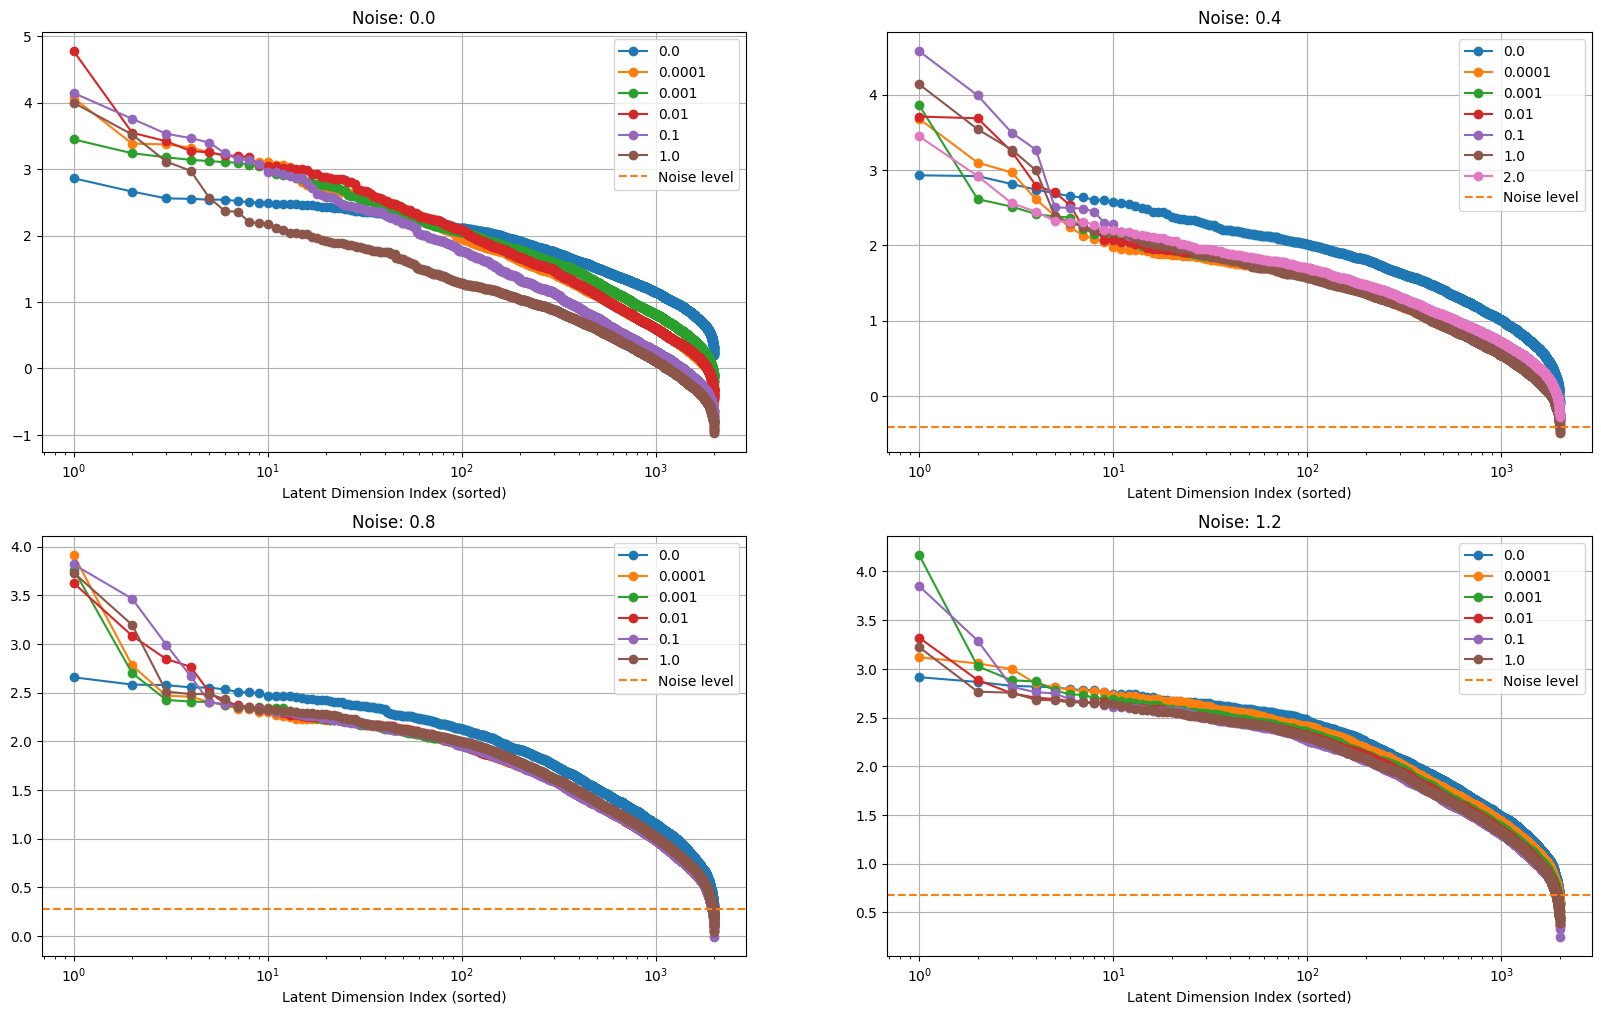

In [52]:
noise_levels = sorted(H_is_ablation.keys())
fig, ax = plt.subplots(
    len(noise_levels) // 2 + len(noise_levels) % 2, 2, figsize=(20, 6 * len(noise_levels) // 2)
)

for i, sigma in enumerate(noise_levels):
    lambda_MTCs = list(H_is_ablation[sigma].keys())
    plot_ME_spectrum(
        list(H_is_ablation[sigma].values()),
        latent_sort=list(latent_sorts_ablation[sigma].values()),
        title=f"Noise: {float(sigma)}",
        sigma_noise=float(sigma),
        names=lambda_MTCs,
        plot_dir=os.path.join(output_dir_path, "plots", f"ME_spectrum_noise_{sigma}.png"),
        log_scale=True,
        ax=ax[i // 2][i % 2],
    )
plt.savefig(os.path.join(output_dir_path, "plots", "ME_spectra_comparison_Noise.png"))
plt.show()

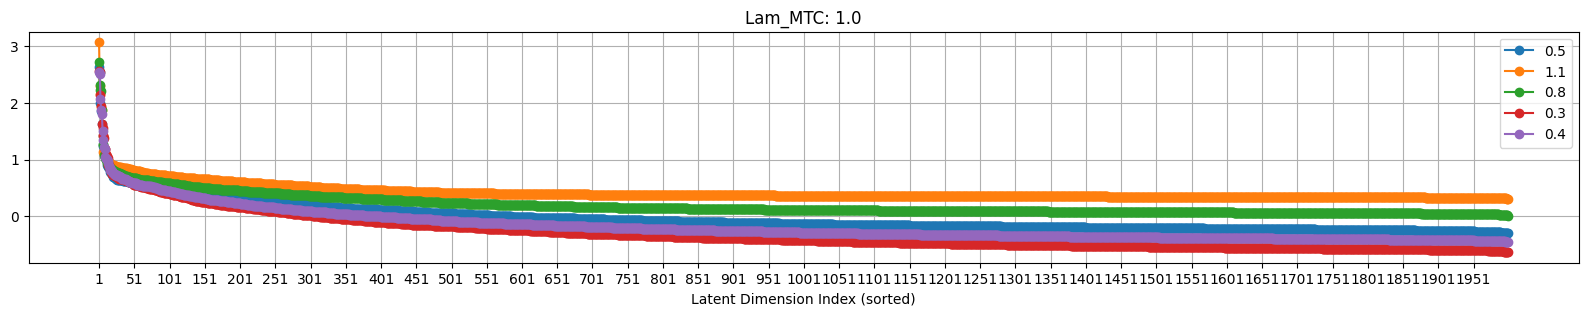

In [ ]:
H_is_ablation_reverse = reverse_dict(H_is_ablation)
latent_sorts_ablation_reverse = reverse_dict(latent_sorts_ablation)

lam_MTCs = sorted(H_is_ablation_reverse.keys())
fig, ax = plt.subplots(
    len(lam_MTCs) // 2 + len(lam_MTCs) % 2, 2, figsize=(20, 6 * len(lam_MTCs) // 2)
)

for i, lam_ in enumerate(lam_MTCs):
    sigma = list(H_is_ablation_reverse[lam_].keys())
    plot_ME_spectrum(
        list(H_is_ablation_reverse[lam_].values()),
        latent_sort=list(latent_sorts_ablation_reverse[lam_].values()),
        title=f"Lam_MTC: {float(lam_)}",
        names=sigma,
        log_scale=True,
        ax=ax[i // 2][i % 2],
    )
plt.savefig(os.path.join(output_dir_path, "plots", "ME_spectra_comparison_Lam.png"))
plt.show()

## 11. Metrics

In [ ]:
dataset_name = "kang"
top_genes = 2000
N_dim = top_genes
D_dim = top_genes
lam_MTC = 1.0
sigma_noise = 0.5

model_dir = os.path.join("/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes))

bottlenecks = [5, 50, 100]
representations = {}

for bottleneck_dim in bottlenecks:
    repr = return_bottleneck_representation(
        adata=adata,
        model_dir=model_dir,
        device=device,
        dtype=dtype,
        sigma_noise=sigma_noise,
        lam_MTC=lam_MTC,
        conditions=None,
        bottleneck_dim=bottleneck_dim,
    )
    representations[bottleneck_dim] = repr
    adata.obsm["X_bottleneck_" + str(bottleneck_dim)] = repr

/home/jhoefer/sandbox/src/analysis/analysis_utils.py:462: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


before forward: 33701.5 MiB
after forward: 33888.7 MiB
after grad: 35841.9 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 7876.32it/s]


before forward: 33762.5 MiB
after forward: 33950.5 MiB
after grad: 35903.6 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 8095.71it/s]


before forward: 33823.6 MiB
after forward: 34010.8 MiB
after grad: 35963.9 MiB


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 7674.36it/s]


In [70]:
gc.collect()
torch.cuda.empty_cache()

In [71]:
adata

AnnData object with n_obs × n_vars = 17913 × 2000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'patient', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_counts', 'sample', 'cell_abbr', '_scvi_batch', '_scvi_labels', 'pca_0', 'pca_1', 'pca_2', 'pca_3', 'latent_886_signed', 'latent_1493_signed', 'latent_1467_signed', 'latent_1578_signed', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'latent_1451_signed', 'latent_127_signed', 'latent_721_signed', 'latent_876_signed'
    var: 'name', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'condition_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', '_scvi_extra_categorical_covs', 'X_scVI', 'X_scVI_un', 'X_bottleneck_5', 'X_bottleneck_50', 'X_bottleneck_100'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [81]:
for key in adata.obsm.keys():
    adata.obsm[key] = adata.obsm[key].astype("float32")
for key in adata.obsp.keys():
    adata.obsp[key] = adata.obsp[key].astype("float32")
adata.X = adata.X.astype("float32")

In [82]:
print(f"{torch.cuda.memory_allocated()/1024**2:.1f} MiB")
adata

12524.4 MiB


AnnData object with n_obs × n_vars = 17913 × 2000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'patient', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_counts', 'sample', 'cell_abbr', '_scvi_batch', '_scvi_labels', 'pca_0', 'pca_1', 'pca_2', 'pca_3', 'latent_886_signed', 'latent_1493_signed', 'latent_1467_signed', 'latent_1578_signed', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'latent_1451_signed', 'latent_127_signed', 'latent_721_signed', 'latent_876_signed'
    var: 'name', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'condition_colors', 'cell_type_colors', 'pca'
    obsm: 'X_pca', 'X_umap', '_scvi_extra_categorical_covs', 'X_scVI', 'X_scVI_un', 'X_bottleneck_5', 'X_bottleneck_50', 'X_bottleneck_100'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [88]:
print(adata.obs["cluster"])

index
AAACATACATTTCC-1    9
AAACATACCAGAAA-1    9
AAACATACCTCGCT-1    9
AAACATACCTGGTA-1    4
AAACATACGATGAA-1    5
                   ..
TTTGCATGCCTGAA-2    6
TTTGCATGCCTGTC-2    4
TTTGCATGCTAAGC-2    6
TTTGCATGGGACGA-2    6
TTTGCATGTCTTAC-2    5
Name: cluster, Length: 17913, dtype: int32


In [83]:
bm_cell_type = Benchmarker(
    adata,
    batch_key="patient",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=[
        "X_pca",
        "X_umap",
        "X_scVI",
        "X_bottleneck_5",
        "X_bottleneck_50",
        "X_bottleneck_100",
    ],
    n_jobs=8,
)
bm_cell_type.benchmark()

Embeddings: 100%|█████████████████████████████████████████████████████████████████████████| 6/6 [05:00<00:00, 50.03s/it]


In [86]:
bm_condition = Benchmarker(
    adata,
    batch_key="patient",
    label_key="condition",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=[
        "X_pca",
        "X_umap",
        "X_scVI",
        "X_bottleneck_5",
        "X_bottleneck_50",
        "X_bottleneck_100",
    ],
    n_jobs=8,
)
bm_condition.benchmark()

Embeddings: 100%|█████████████████████████████████████████████████████████████████████████| 6/6 [03:15<00:00, 32.57s/it]


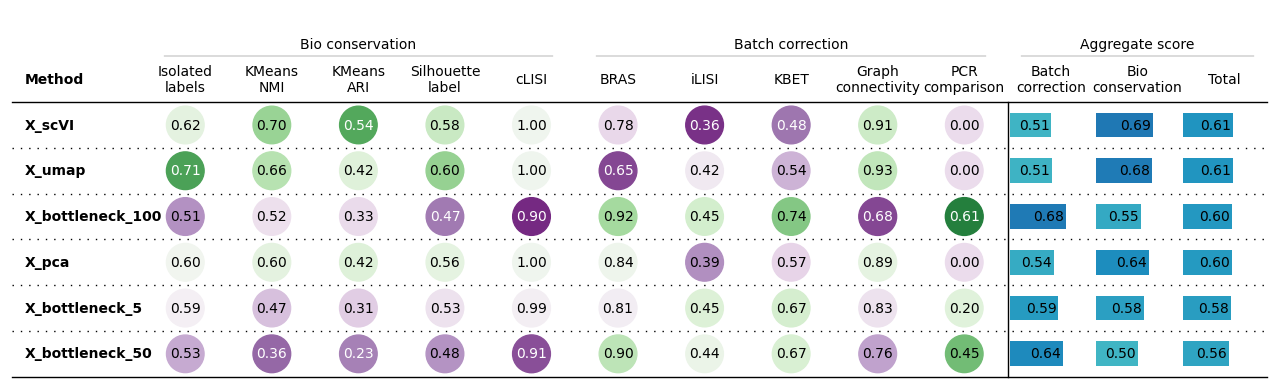

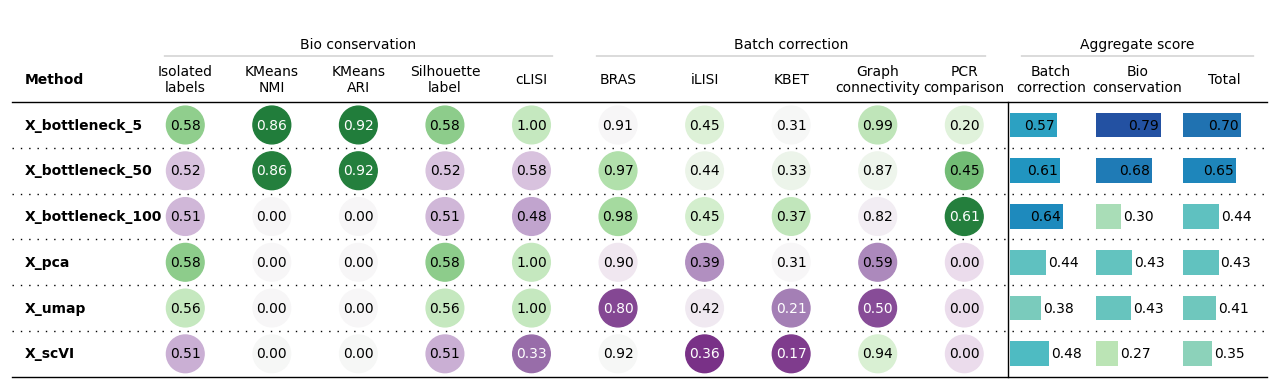

In [87]:
bm_cell_type.plot_results_table()
bm_condition.plot_results_table()